100%|██████████| 175/175 [11:22<00:00,  3.90s/it]


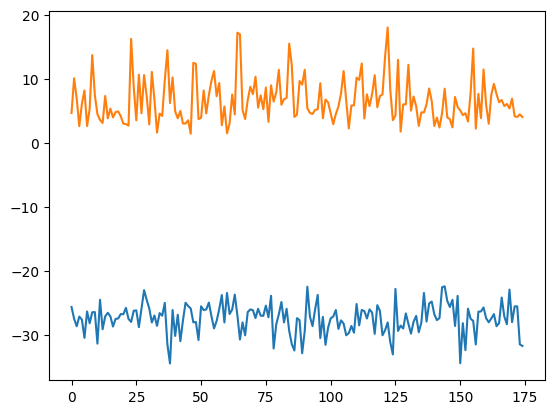

In [2]:
import numpy as np
import os
import essentia
import essentia.standard as es
import tqdm

import matplotlib.pyplot as plt
from pylab import plot, show, figure, imshow


SSL_DSET_PATH = "/Volumes/Saola's Drive/allCode/thesis/data/Diff-SSL-G-Comp"

DRY_PATH = 'processed_normalized'
WET_PATH = 'processed_ground_truth'

def load_audio_files(root_dir):
    audio_files = []
    for file in os.listdir(root_dir):
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root_dir, file))
    return audio_files

def load_audio(path):
    audio_st, sr, _, _, _, _ = es.AudioLoader(filename=path)()
    return audio_st, sr

def get_audio_stats(audio, sr):
    _, _, ebu_integrated, loudness_range = es.LoudnessEBUR128(hopSize=1024/sr, startAtZero=True)(audio)
    return ebu_integrated, loudness_range


files = load_audio_files(os.path.join(SSL_DSET_PATH, DRY_PATH))

stats = []
for file in tqdm.tqdm(files):
    audio, sr = load_audio(file)
    loudness, loudness_range = get_audio_stats(audio, sr)
    stats.append((loudness, loudness_range))
 
plot(stats)

In [ ]:
files = load_audio_files(os.path.join(SSL_DSET_PATH, DRY_PATH))

peakstats = []
for file in tqdm.tqdm(files):
    audio, sr = load_audio(file)
    peak = np.max(np.absolute(audio))
    peakstats.append(peak)

100%|██████████| 175/175 [00:26<00:00,  6.72it/s]


In [ ]:
print(peakstats)

[np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32

In [ ]:
k = 30
top_idx = np.argsort(np_stats[:, 0])[-k:][::-1]
top_loudness = np_stats[top_idx]
files_array = np.array(files)
top_files = files_array[top_idx]

d = 10
top_d_idx = np.argsort(top_loudness[:, 1])[-d:][::-1]
top_d_loudness = top_loudness[top_d_idx]   
top_d_files = top_files[top_d_idx]

print(top_d_loudness)
print(top_d_files)

[[-23.03463745  10.55282784]
 [-25.205513    10.14929199]
 [-25.02567673   9.76595116]
 [-23.91552162   8.95453262]
 [-25.45764351   8.61070061]
 [-25.12249947   8.46343422]
 [-22.44111633   8.42574883]
 [-24.98106575   7.44207191]
 [-24.54237938   7.27855682]
 [-24.19542122   6.66007233]]
['/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/NosPalpitants_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/AncoraQui_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/SongForJohn_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/Air_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/OpenFire_UnmasteredWAV.wav'
 '/Volumes/Production Too

## Subset selection plot

Visualise the chosen subset in the **integrated loudness** (LUFS) vs **loudness range** (LU) plane. The two-stage rule is shown directly: first keep the `k = 30` loudest tracks (right of the vertical cut), then keep the `d = 10` of those with the widest dynamic range (above the horizontal cut). The shaded corner is the resulting selection region and the chosen tracks are labelled.

Saved figure to /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/01_dset_filtering/figures/ssl_subset_selection.pdf


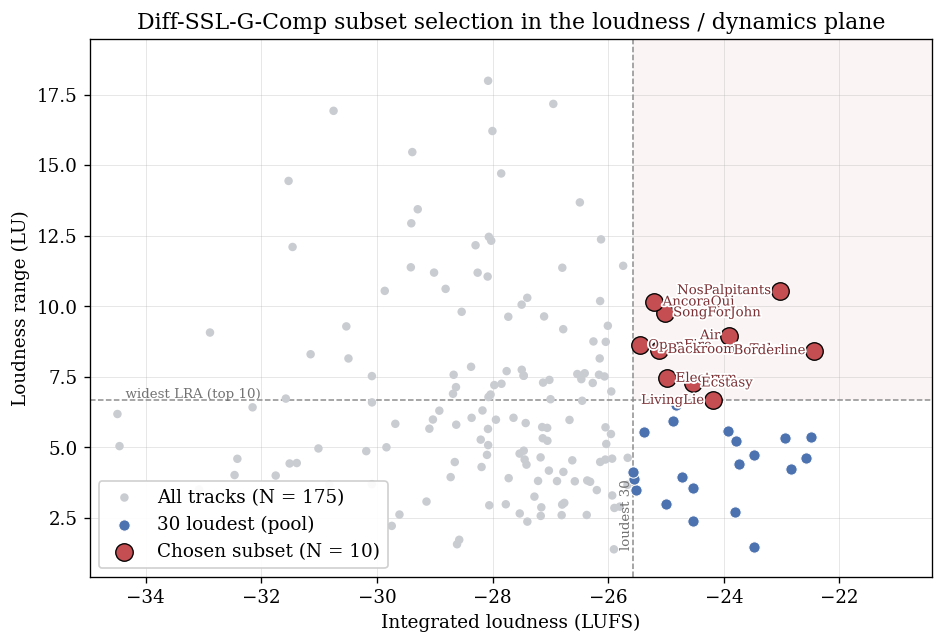

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle

# --- Reproduce the subset selection (kept self-contained) ---------------------
np_stats = np.asarray(stats, dtype=float)            # [N, 2]: (integrated loudness, loudness range)
loudness_all, lra_all = np_stats[:, 0], np_stats[:, 1]

k, d = 30, 10
pool_idx   = np.argsort(loudness_all)[-k:][::-1]     # k loudest tracks (selection pool)
pool_stats = np_stats[pool_idx]
sel_local  = np.argsort(pool_stats[:, 1])[-d:][::-1] # d widest loudness range within the pool
sel_idx    = pool_idx[sel_local]                     # -> global indices of the chosen subset

is_pool   = np.zeros(len(np_stats), dtype=bool); is_pool[pool_idx] = True
is_chosen = np.zeros(len(np_stats), dtype=bool); is_chosen[sel_idx] = True

# thresholds that define the selection region
loud_thresh = pool_stats[:, 0].min()                 # quietest track that still made the loud pool
lra_thresh  = np_stats[sel_idx, 1].min()             # narrowest LRA among the chosen subset

def track_name(p):
    return os.path.basename(p).replace('_UnmasteredWAV.wav', '').replace('_', ' ')

# --- Thesis-style figure ------------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.axisbelow': True, 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linewidth': 0.6,
    'savefig.bbox': 'tight', 'figure.dpi': 120,
})

C_REST, C_POOL, C_SEL = '#c9ccd1', '#4c72b0', '#c44e52'
fig, ax = plt.subplots(figsize=(8, 5.5))

# axis limits with headroom so labels stay inside the frame
x_lo, x_hi = loudness_all.min(), loudness_all.max()
y_lo, y_hi = lra_all.min(), lra_all.max()
xs, ys = x_hi - x_lo, y_hi - y_lo
ax.set_xlim(x_lo - 0.04 * xs, x_hi + 0.17 * xs)
ax.set_ylim(y_lo - 0.06 * ys, y_hi + 0.09 * ys)

# shaded selection region: loud enough AND wide enough dynamic range
ax.add_patch(Rectangle((loud_thresh, lra_thresh), 1e3, 1e3,
                       facecolor=C_SEL, alpha=0.06, edgecolor='none', zorder=0))
ax.axvline(loud_thresh, color='0.55', ls='--', lw=0.9, zorder=1)
ax.axhline(lra_thresh,  color='0.55', ls='--', lw=0.9, zorder=1)
ax.text(loud_thresh, y_lo, f'loudest {k}  ', color='0.45', fontsize=8,
        rotation=90, va='bottom', ha='right')
ax.text(x_lo, lra_thresh, f'  widest LRA (top {d})', color='0.45', fontsize=8,
        va='bottom', ha='left')

# all 175 tracks
ax.scatter(loudness_all[~is_pool], lra_all[~is_pool],
           s=26, c=C_REST, edgecolors='none', zorder=2,
           label=f'All tracks (N = {len(np_stats)})')
# loud pool, not finally chosen
mask_pool_only = is_pool & ~is_chosen
ax.scatter(loudness_all[mask_pool_only], lra_all[mask_pool_only],
           s=46, c=C_POOL, edgecolors='white', linewidths=0.6, zorder=3,
           label=f'{k} loudest (pool)')
# chosen subset
ax.scatter(loudness_all[is_chosen], lra_all[is_chosen],
           s=110, c=C_SEL, edgecolors='black', linewidths=0.8, marker='o', zorder=5,
           label=f'Chosen subset (N = {d})')

# annotate the chosen tracks; flip near the right edge so labels stay in-frame
x_flip = x_hi - 0.16 * xs
texts = []
for i in sel_idx:
    right = loudness_all[i] <= x_flip
    label = ('  ' if right else '') + track_name(files[i]) + ('' if right else '  ')
    texts.append(ax.text(loudness_all[i], lra_all[i], label,
                         fontsize=8, color='#7a2f33', zorder=6, va='center',
                         ha='left' if right else 'right',
                         path_effects=[pe.withStroke(linewidth=2.2, foreground='white')]))

# auto de-overlap labels if adjustText is available (`uv add adjustText`)
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax, only_move={'text': 'y'}, expand=(1.05, 1.5),
                arrowprops=dict(arrowstyle='-', color='0.55', lw=0.6))
except ImportError:
    pass

ax.set_xlabel('Integrated loudness (LUFS)')
ax.set_ylabel('Loudness range (LU)')
ax.set_title('Diff-SSL-G-Comp subset selection in the loudness / dynamics plane')
ax.legend(loc='lower left', framealpha=0.92, edgecolor='0.8')
fig.tight_layout()

# save a thesis-ready copy (vector + raster)
out_dir = 'figures'
os.makedirs(out_dir, exist_ok=True)
for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(out_dir, f'ssl_subset_selection.{ext}'), dpi=300)
print('Saved figure to', os.path.abspath(os.path.join(out_dir, 'ssl_subset_selection.pdf')))
plt.show()